In [ ]:
import ee,sys
def init_ee(project_id=None):
    """
    Authenticates and initializes Google Earth Engine.
    """
    print("Checking Earth Engine session...")
    try:
        ee.Initialize(project=project_id) if project_id else ee.Initialize()
        print("Earth Engine is already initialized.")
    except Exception as _:
        print("No active session. Starting authentication flow...")
        ee.Authenticate()
        ee.Initialize(project=project_id) if project_id else ee.Initialize()
        print("Earth Engine initialized after authentication.")
    finally:

        pv = sys.version.split()[0]
        print(f"Python {pv} | EE project: {project_id if project_id else 'default'}")

EE_PROJECT_ID = "replicating-paper"

init_ee(EE_PROJECT_ID)


Checking Earth Engine session...
No active session. Starting authentication flow...
Earth Engine initialized after authentication.
Python 3.12.12 | EE project: replicating-paper


In [ ]:


try:
    print("\nCollecting dataset metadata...\n")

    datasets = {
        "Sentinel-2 Surface Reflectance (NDVI)": {
            "id": "COPERNICUS/S2_SR",
            "start": "2015-06-23",
            "resolution": "10m",
            "bands": ["B4 (Red)", "B8 (NIR)"]
        },
        "MODIS NDVI (MOD13Q1)": {
            "id": "MODIS/006/MOD13Q1",
            "start": "2000-02-18",
            "resolution": "250m",
            "bands": ["NDVI", "EVI", "Summary QA"]
        },
        "GEDI Canopy Height (GEDI L4A)": {
            "id": "LARSE/GEDI/GEDI02_A_002_MONTHLY",
            "start": "2019-04-18",
            "resolution": "~25m footprints",
            "bands": ["rh98", "canopy_top", "elev_highestreturn"]
        },
        "Hansen Global Forest Change v1.10": {
            "id": "UMD/hansen/global_forest_change_2022_v1_10",
            "start": "2000-01-01",
            "resolution": "30m",
            "bands": ["treecover2000", "lossyear", "gain", "loss", "datamask"]
        },
        "MODIS Burned Area (MCD64A1)": {
            "id": "MODIS/006/MCD64A1",
            "start": "2000-11-01",
            "resolution": "500m",
            "bands": ["BurnDate", "FirstDay", "LastDay", "QA"]
        },
        "WorldClim Bioclimatic Variables (V1)": {
            "id": "WORLDCLIM/V1/BIO",
            "start": "1970-01-01",
            "resolution": "1km (~30 arc-seconds)",
            "bands": ["BIO1 - BIO19"]
        }
    }

    for name, meta in datasets.items():
        print("Dataset:", name)
        print("  GEE ID:", meta["id"])
        print("  Available From:", meta["start"])
        print("  Spatial Resolution:", meta["resolution"])
        print("  Bands:", ', '.join(meta["bands"]))
        print("-" * 50)

except Exception as e:
    print("Error loading dataset metadata.")
    print(str(e))




Dataset: Sentinel-2 Surface Reflectance (NDVI)
  GEE ID: COPERNICUS/S2_SR
  Available From: 2015-06-23
  Spatial Resolution: 10m
  Bands: B4 (Red), B8 (NIR)
--------------------------------------------------
Dataset: MODIS NDVI (MOD13Q1)
  GEE ID: MODIS/006/MOD13Q1
  Available From: 2000-02-18
  Spatial Resolution: 250m
  Bands: NDVI, EVI, Summary QA
--------------------------------------------------
Dataset: GEDI Canopy Height (GEDI L4A)
  GEE ID: LARSE/GEDI/GEDI02_A_002_MONTHLY
  Available From: 2019-04-18
  Spatial Resolution: ~25m footprints
  Bands: rh98, canopy_top, elev_highestreturn
--------------------------------------------------
Dataset: Hansen Global Forest Change v1.10
  GEE ID: UMD/hansen/global_forest_change_2022_v1_10
  Available From: 2000-01-01
  Spatial Resolution: 30m
  Bands: treecover2000, lossyear, gain, loss, datamask
--------------------------------------------------
Dataset: MODIS Burned Area (MCD64A1)
  GEE ID: MODIS/006/MCD64A1
  Available From: 2000-11-0

In [ ]:


try:

    SELECT_REGION = "sanjay_van"


    REGIONS = {
        "sanjay_van": {
            "name": "Sanjay Van (Delhi) — urban dry-deciduous / scrub woodland",
            "bbox": [77.17, 28.52, 77.18, 28.54],
        },
        "sundarbans": {
            "name": "Sundarbans — coastal mangrove (tidal)",
            "bbox": [88.85, 21.85, 88.87, 21.87],
        },
        "western_ghats": {
            "name": "Western Ghats — tropical evergreen / montane",
            "bbox": [75.74, 11.27, 75.76, 11.29],
        },
        "himalayas": {
            "name": "Himalayas — sub-alpine / alpine (rugged)",
            "bbox": [78.40, 33.20, 78.42, 33.22],
        }
    }

    if SELECT_REGION not in REGIONS:
        raise ValueError(f"Region '{SELECT_REGION}' is not defined in REGIONS dictionary.")


    region_info = REGIONS[SELECT_REGION]
    region_name = region_info["name"]
    region_bbox = region_info["bbox"]


    aoi = ee.Geometry.Rectangle(region_bbox)


    print("Selected Region:", SELECT_REGION)
    print("Region Name:", region_name)
    print("Bounding Box (minLon, minLat, maxLon, maxLat):", region_bbox)
    print("Geometry Type:", aoi.type().getInfo())

except Exception as e:
    print("Error defining AOI.")
    print(str(e))


Selected Region: sanjay_van
Region Name: Sanjay Van (Delhi) — urban dry-deciduous / scrub woodland
Bounding Box (minLon, minLat, maxLon, maxLat): [77.17, 28.52, 77.18, 28.54]
Geometry Type: Polygon


In [ ]:


try:
    import datetime

    print(f"Checking dataset availability for region: {SELECT_REGION}\n")


    test_start = '2021-01-01'
    test_end = '2021-12-31'


    test_datasets = {
        "Sentinel-2 SR": {
            "id": "COPERNICUS/S2_SR",
            "filter": lambda col: col.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)),
        },
        "MODIS NDVI": {
            "id": "MODIS/006/MOD13Q1",
            "filter": lambda col: col,
        },
        "GEDI L2A Canopy Height": {
            "id": "LARSE/GEDI/GEDI02_A_002_MONTHLY",
            "filter": lambda col: col,
        },
        "Hansen Forest Change": {
            "id": "UMD/hansen/global_forest_change_2022_v1_10",
            "static": True,
        },
        "MODIS Burned Area": {
            "id": "MODIS/006/MCD64A1",
            "filter": lambda col: col,
        },
        "WorldClim Bioclim (V1)": {
            "id": "WORLDCLIM/V1/BIO",
            "static": True,
        }
    }

    for name, ds in test_datasets.items():
        print(f"Dataset: {name}")
        dataset_id = ds["id"]
        is_static = ds.get("static", False)

        try:
            if is_static:
                image = ee.Image(dataset_id)
                band_names = image.bandNames().getInfo()
                print(f"  ✓ Static dataset loaded. Bands: {band_names}")

            else:
                collection = ee.ImageCollection(dataset_id) \
                    .filterDate(test_start, test_end) \
                    .filterBounds(aoi)

                if "filter" in ds:
                    collection = ds["filter"](collection)

                count = collection.size().getInfo()
                if count > 0:
                    first_img = collection.first()
                    band_names = first_img.bandNames().getInfo()
                    date_str = ee.Date(first_img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
                    print(f"  ✓ {count} image(s) available. First image date: {date_str}")
                    print(f"    Bands: {band_names}")
                else:
                    print("  ✗ No data available for selected AOI and date range.")

        except Exception as e:
            print(f"  ✗ Failed to load or query dataset.")
            print("   Error:", str(e))

        print("-" * 60)

except Exception as e:
    print("Fatal error during dataset verification.")
    print(str(e))


Checking dataset availability for region: sanjay_van

Dataset: Sentinel-2 SR


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


  ✓ 37 image(s) available. First image date: 2021-01-19
    Bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60']
------------------------------------------------------------
Dataset: MODIS NDVI


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for MODIS/006/MOD13Q1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MOD13Q1

  warnings.warn(warning, category=DeprecationWarning)


  ✓ 23 image(s) available. First image date: 2021-01-01
    Bands: ['NDVI', 'EVI', 'DetailedQA', 'sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03', 'sur_refl_b07', 'ViewZenith', 'SolarZenith', 'RelativeAzimuth', 'DayOfYear', 'SummaryQA']
------------------------------------------------------------
Dataset: GEDI L2A Canopy Height
  ✓ 12 image(s) available. First image date: 2021-01-01
    Bands: ['beam', 'degrade_flag', 'delta_time', 'digital_elevation_model', 'digital_elevation_model_srtm', 'elev_highestreturn', 'elev_lowestmode', 'elevation_bias_flag', 'energy_total', 'landsat_treecover', 'landsat_water_persistence', 'lat_highestreturn', 'leaf_off_doy', 'leaf_off_flag', 'leaf_on_cycle', 'leaf_on_doy', 'lon_highestreturn', 'modis_nonvegetated', 'modis_nonvegetated_sd', 'modis_treecover', 'modis_treecover_sd', 'num_detectedmodes', 'pft_class', 'quality_flag', 'region_class', 'selected_algorithm', 'selected_mode', 'selected_mode_flag', 'sensitivity', 'solar_azimuth', 'solar_elevation', 'sur

/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for UMD/hansen/global_forest_change_2022_v1_10! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/UMD_hansen_global_forest_change_2022_v1_10

  warnings.warn(warning, category=DeprecationWarning)
/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for MODIS/006/MCD64A1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MCD64A1

  warnings.warn(warning, category=DeprecationWarning)


  ✓ 12 image(s) available. First image date: 2021-01-01
    Bands: ['BurnDate', 'Uncertainty', 'QA', 'FirstDay', 'LastDay']
------------------------------------------------------------
Dataset: WorldClim Bioclim (V1)
  ✓ Static dataset loaded. Bands: ['bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
------------------------------------------------------------


In [ ]:


try:
    print(f"Checking full dataset availability for region: {SELECT_REGION}\n")

    test_start = '2021-01-01'
    test_end = '2021-12-31'

    test_datasets = {
        "Sentinel-2 SR (Harmonized)": {
            "id": "COPERNICUS/S2_SR_HARMONIZED",
            "filter": lambda col: col.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        },
        "MODIS NDVI (v061)": {
            "id": "MODIS/061/MOD13Q1",
            "filter": lambda col: col
        },
        "MODIS Burned Area (v061)": {
            "id": "MODIS/061/MCD64A1",
            "filter": lambda col: col
        },
        "GEDI L2A Canopy Height": {
            "id": "LARSE/GEDI/GEDI02_A_002_MONTHLY",
            "filter": lambda col: col
        },
        "Hansen Forest Change": {
            "id": "UMD/hansen/global_forest_change_2022_v1_10",
            "static": True
        },
        "WorldClim Bioclim": {
            "id": "WORLDCLIM/V1/BIO",
            "static": True
        },
        "Landsat 8 SR (Tier 1)": {
            "id": "LANDSAT/LC08/C02/T1_L2",
            "filter": lambda col: col.filter(ee.Filter.lt('CLOUD_COVER', 20))
        },
        "Sentinel-1 SAR GRD": {
            "id": "COPERNICUS/S1_GRD",
            "filter": lambda col: col.filter(ee.Filter.eq('instrumentMode', 'IW')).filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        },
        "Dynamic World LULC": {
            "id": "GOOGLE/DYNAMICWORLD/V1",
            "filter": lambda col: col
        },
        "SRTM Elevation": {
            "id": "USGS/SRTMGL1_003",
            "static": True
        }
    }

    for name, ds in test_datasets.items():
        print(f"Dataset: {name}")
        dataset_id = ds["id"]
        is_static = ds.get("static", False)

        try:
            if is_static:
                image = ee.Image(dataset_id)
                band_names = image.bandNames().getInfo()
                print(f"  ✓ Static dataset loaded. Bands: {band_names}")
            else:
                collection = ee.ImageCollection(dataset_id) \
                    .filterDate(test_start, test_end) \
                    .filterBounds(aoi)

                if "filter" in ds:
                    collection = ds["filter"](collection)

                count = collection.size().getInfo()
                if count > 0:
                    first_img = collection.first()
                    band_names = first_img.bandNames().getInfo()
                    date_str = ee.Date(first_img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
                    print(f"  ✓ {count} image(s) available. First image date: {date_str}")
                    print(f"    Bands: {band_names}")
                else:
                    print("  ✗ No data available for selected AOI and date range.")

        except Exception as e:
            print("  ✗ Failed to load or query dataset.")
            print("   Error:", str(e))

        print("-" * 60)

except Exception as e:
    print("Fatal error during dataset verification.")
    print(str(e))


Checking full dataset availability for region: sanjay_van

Dataset: Sentinel-2 SR (Harmonized)
  ✓ 37 image(s) available. First image date: 2021-01-19
    Bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']
------------------------------------------------------------
Dataset: MODIS NDVI (v061)
  ✓ 23 image(s) available. First image date: 2021-01-01
    Bands: ['NDVI', 'EVI', 'DetailedQA', 'sur_refl_b01', 'sur_refl_b02', 'sur_refl_b03', 'sur_refl_b07', 'ViewZenith', 'SolarZenith', 'RelativeAzimuth', 'DayOfYear', 'SummaryQA']
------------------------------------------------------------
Dataset: MODIS Burned Area (v061)
  ✓ 12 image(s) available. First image date: 2021-01-01
    Bands: ['BurnDate', 'Uncertainty', 'QA', 'FirstDay', 'LastDay']
-------------------------------------------------------

In [ ]:


try:
    import math


    start_date = '2018-01-01'
    end_date = '2023-12-31'

    print("Loading Sentinel-2 Harmonized for NDVI/NIRv computation...")
    s2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(aoi) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .select(['B4', 'B8'])

    def add_indices(img):
        red = img.select('B4')
        nir = img.select('B8')
        ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
        nirv = ndvi.multiply(nir).rename('NIRv')
        return img.addBands([ndvi, nirv])

    print("Calculating NDVI and NIRv for each image...")
    s2_with_indices = s2.map(add_indices)

    print("Grouping into monthly composites...")
    def get_monthly_mean(year, month):
        start = ee.Date.fromYMD(year, month, 1)
        end = start.advance(1, 'month')
        filtered = s2_with_indices.filterDate(start, end)
        return filtered.mean() \
            .set('system:time_start', start.millis()) \
            .set('year', year) \
            .set('month', month)


    years = list(range(2018, 2024))
    months = list(range(1, 13))
    monthly_images = []

    for year in years:
        for month in months:
            monthly_images.append(get_monthly_mean(year, month))


    monthly_ic = ee.ImageCollection(ee.List(monthly_images))
    print("Monthly composites created:", monthly_ic.size().getInfo())



    print("Preparing harmonic regression on NDVI...")


    def add_time_bands(img):
      date = ee.Date(img.get('system:time_start'))
      time_radians = date.difference(ee.Date(start_date), 'day') \
          .multiply(2 * math.pi / 365.25)
      time_img = ee.Image.constant(time_radians).rename('t_rad')
      cos = time_img.cos().rename('cos')
      sin = time_img.sin().rename('sin')
      return img.addBands([cos, sin])


    with_time = monthly_ic.map(add_time_bands)


    regression = with_time.select(['cos', 'sin', 'NDVI']) \
        .reduce(ee.Reducer.linearRegression(numX=2, numY=1))

    coefficients = regression.select('coefficients')
    a1 = coefficients.arrayGet([0, 0]).rename('a1')
    b1 = coefficients.arrayGet([1, 0]).rename('b1')


    a0 = monthly_ic.select('NDVI').mean().rename('NDVI_mean')
    amplitude = a1.pow(2).add(b1.pow(2)).sqrt().rename('NDVI_amplitude')
    phase = b1.atan2(a1).rename('NDVI_phase')


    mean_nirv = monthly_ic.select('NIRv').mean().rename('NIRv_mean')


    phenology_features = a0.addBands([amplitude, phase, mean_nirv])
    print("Harmonic features ready: NDVI_mean, NDVI_amplitude, NDVI_phase, NIRv_mean")

except Exception as e:
    print("Error during harmonic regression or index calculation.")
    print(str(e))


try:
    print("Sampling summary stats for derived harmonic features...")

    stat_dict = phenology_features.reduceRegion(
        reducer=ee.Reducer.minMax().combine(
            reducer2=ee.Reducer.mean(), sharedInputs=True
        ),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).getInfo()

    for key, value in stat_dict.items():
        print(f"{key}: {round(value, 4)}")

except Exception as e:
    print("Error computing summary stats.")
    print(str(e))


try:
    print("\nSampling pixel values at 5 random locations in AOI:")

    samples = phenology_features.sample(
        region=aoi,
        scale=10,
        numPixels=5,
        seed=42,
        geometries=True
    ).getInfo()

    for i, feature in enumerate(samples['features']):
        props = feature['properties']
        coords = feature['geometry']['coordinates']
        print(f"\nSample {i+1} at {coords}:")
        for k, v in props.items():
            print(f"  {k}: {round(v, 4)}")

except Exception as e:
    print("Error sampling pixel values.")
    print(str(e))



Loading Sentinel-2 Harmonized for NDVI/NIRv computation...
Calculating NDVI and NIRv for each image...
Grouping into monthly composites...
Monthly composites created: 72
Preparing harmonic regression on NDVI...
Harmonic features ready: NDVI_mean, NDVI_amplitude, NDVI_phase, NIRv_mean
Sampling summary stats for derived harmonic features...
NDVI_amplitude_max: 0.2607
NDVI_amplitude_mean: 0.1357
NDVI_amplitude_min: 0.0016
NDVI_mean_max: 0.7333
NDVI_mean_mean: 0.4627
NDVI_mean_min: -0.0015
NDVI_phase_max: 3.0667
NDVI_phase_mean: 1.5561
NDVI_phase_min: -3.0464
NIRv_mean_max: 2819.5872
NIRv_mean_mean: 1193.1767
NIRv_mean_min: -6.5949

Sampling pixel values at 5 random locations in AOI:

Sample 1 at [77.17309605755703, 28.525685091541625]:
  NDVI_amplitude: 0.186
  NDVI_mean: 0.5901
  NDVI_phase: 1.9333
  NIRv_mean: 1682.0813

Sample 2 at [77.17220741738436, 28.532264147902815]:
  NDVI_amplitude: 0.1885
  NDVI_mean: 0.5956
  NDVI_phase: 1.6043
  NIRv_mean: 1493.9967

Sample 3 at [77.176176669

In [ ]:


try:
    print("Loading MODIS Burned Area collection...")
    burn_collection = ee.ImageCollection("MODIS/061/MCD64A1") \
        .filterBounds(aoi) \
        .filterDate("2000-01-01", "2023-12-31") \
        .select('BurnDate')

    print("Tagging each image with its burn year...")
    def tag_year(img):
        burn_year = ee.Date(img.get('system:time_start')).get('year')
        img = img.updateMask(img.gt(0))
        return img.set('burn_year', burn_year)

    burn_years = burn_collection.map(tag_year)

    print("Adding burn_year band with consistent int16 type...")
    def add_burn_year_band(img):
        year = ee.Number(img.get('burn_year'))
        year_img = ee.Image.constant(year).toInt16().rename('burn_year')
        return img.addBands(year_img)

    burn_with_year = burn_years.map(add_burn_year_band)

    print("Reducing to pixel-wise most recent burn year...")
    last_burn_img = burn_with_year.qualityMosaic('burn_year')
    last_burn_year = last_burn_img.select('burn_year')

    print("Calculating time since last burn (in years)...")
    current_year = 2023
    time_since_burn = ee.Image.constant(current_year).subtract(last_burn_year).rename('years_since_burn')

    print("Sampling summary stats for time since last burn...")
    burn_stats = time_since_burn.reduceRegion(
        reducer=ee.Reducer.minMax().combine(
            ee.Reducer.mean(), sharedInputs=True
        ),
        geometry=aoi,
        scale=500,
        maxPixels=1e9
    ).getInfo()

    for key, val in burn_stats.items():
        print(f"{key}: {round(val, 2)}")

except Exception as e:
    print("Error while computing time since last burn.")
    print(str(e))


Loading MODIS Burned Area collection...
Tagging each image with its burn year...
Adding burn_year band with consistent int16 type...
Reducing to pixel-wise most recent burn year...
Calculating time since last burn (in years)...
Sampling summary stats for time since last burn...
years_since_burn_max: 0
years_since_burn_mean: 0
years_since_burn_min: 0


In [ ]:


try:
    print("Loading Hansen Global Forest Change (v1.10)...")

    hansen = ee.Image("UMD/hansen/global_forest_change_2022_v1_10")

    treecover2000 = hansen.select('treecover2000')
    loss = hansen.select('loss')
    lossyear = hansen.select('lossyear')

    print("Creating forest mask for pixels with cover >10% in year 2000...")
    forest2000 = treecover2000.gte(10)

    print("Computing year of last loss...")

    loss_year = lossyear.updateMask(loss).add(2000).rename('loss_year')

    print("Computing canopy persistence (years since last forest loss)...")

    current_year = 2023
    years_since_loss = ee.Image(current_year).subtract(loss_year).rename('years_since_loss')


    full_persistence = ee.Image.constant(current_year - 2000).rename('years_since_loss')
    canopy_persistence = years_since_loss.unmask(full_persistence)


    canopy_persistence = canopy_persistence.updateMask(forest2000)

    print("Sampling summary stats for canopy persistence...")
    persist_stats = canopy_persistence.reduceRegion(
        reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), sharedInputs=True),
        geometry=aoi,
        scale=30,
        maxPixels=1e9
    ).getInfo()

    for key, val in persist_stats.items():
        print(f"{key}: {round(val, 2)}")

except Exception as e:
    print("Error computing canopy persistence.")
    print(str(e))


Loading Hansen Global Forest Change (v1.10)...
Creating forest mask for pixels with cover >10% in year 2000...
Computing year of last loss...
Computing canopy persistence (years since last forest loss)...
Sampling summary stats for canopy persistence...
years_since_loss_max: 23
years_since_loss_mean: 23
years_since_loss_min: 23


In [ ]:


try:
    print("Loading SRTM Elevation data...")
    srtm = ee.Image("USGS/SRTMGL1_003").clip(aoi)

    print("Computing slope and aspect from elevation...")
    terrain = ee.Terrain.products(srtm)
    elevation = terrain.select('elevation')
    slope = terrain.select('slope')
    aspect = terrain.select('aspect')

    print("Stacking terrain bands into one image...")
    terrain_features = elevation.rename('elevation') \
        .addBands(slope.rename('slope')) \
        .addBands(aspect.rename('aspect'))

    print("Sampling summary stats for terrain layers...")
    terrain_stats = terrain_features.reduceRegion(
        reducer=ee.Reducer.minMax().combine(
            ee.Reducer.mean(), sharedInputs=True
        ),
        geometry=aoi,
        scale=30,
        maxPixels=1e9
    ).getInfo()

    for key, val in terrain_stats.items():
        print(f"{key}: {round(val, 2)}")

except Exception as e:
    print("Error while extracting topographic features.")
    print(str(e))


Loading SRTM Elevation data...
Computing slope and aspect from elevation...
Stacking terrain bands into one image...
Sampling summary stats for terrain layers...
aspect_max: 354
aspect_mean: 159.96
aspect_min: 0
elevation_max: 280
elevation_mean: 254.92
elevation_min: 228
slope_max: 14
slope_mean: 3.83
slope_min: 0


In [ ]:


try:
    print("Stacking all derived features into one image...")


    final_features = phenology_features \
        .addBands(time_since_burn) \
        .addBands(canopy_persistence) \
        .addBands(terrain_features)

    print("Sampling 10 random pixels within AOI...")
    sampled_pixels = final_features.sample(
        region=aoi,
        scale=30,
        numPixels=10,
        seed=42,
        geometries=True
    ).getInfo()

    print("\n--- Sampled Pixel Feature Vectors ---")
    for i, feature in enumerate(sampled_pixels['features']):
        props = feature['properties']
        coords = feature['geometry']['coordinates']
        print(f"\nPixel {i+1} at [lon: {round(coords[0], 5)}, lat: {round(coords[1], 5)}]")
        for key, val in props.items():
            print(f"  {key}: {round(val, 4) if isinstance(val, (float, int)) else val}")

except Exception as e:
    print("Error sampling pixel feature vectors.")
    print(str(e))


Stacking all derived features into one image...
Sampling 10 random pixels within AOI...

--- Sampled Pixel Feature Vectors ---

Pixel 1 at [lon: 77.17221, lat: 28.53226]
  NDVI_amplitude: 0.1881
  NDVI_mean: 0.6058
  NDVI_phase: 1.5463
  NIRv_mean: 1499.6459
  aspect: 82
  elevation: 250
  slope: 6
  years_since_burn: 0
  years_since_loss: 23

Pixel 2 at [lon: 77.17517, lat: 28.52853]
  NDVI_amplitude: 0.1365
  NDVI_mean: 0.5742
  NDVI_phase: 1.5205
  NIRv_mean: 1356.3862
  aspect: 311
  elevation: 250
  slope: 4
  years_since_burn: 0
  years_since_loss: 23

Pixel 3 at [lon: 77.17587, lat: 28.53307]
  NDVI_amplitude: 0.2097
  NDVI_mean: 0.6611
  NDVI_phase: 1.6105
  NIRv_mean: 1854.7059
  aspect: 140
  elevation: 243
  slope: 5
  years_since_burn: 0
  years_since_loss: 23

Pixel 4 at [lon: 77.17235, lat: 28.53246]
  NDVI_amplitude: 0.1881
  NDVI_mean: 0.6058
  NDVI_phase: 1.5463
  NIRv_mean: 1499.6459
  aspect: 82
  elevation: 250
  slope: 6
  years_since_burn: 0
  years_since_loss: 23

In [ ]:


try:
    print("Loading GEDI L2A dataset (2019–2023)...")
    gedi = ee.ImageCollection("LARSE/GEDI/GEDI02_A_002_MONTHLY") \
        .filterBounds(aoi) \
        .filterDate("2019-01-01", "2023-03-31") \
        .select(['rh25', 'rh50', 'rh75', 'rh98', 'rh100'])

    count = gedi.size().getInfo()
    print(f"Found {count} GEDI shots in AOI.")

    if count == 0:
        print("No GEDI data available in this AOI.")
    else:
        gedi_all = gedi.first()

        print("Sampling 10 GEDI shots with RH metrics...")
        gedi_samples = gedi_img.sample(
            region=aoi,
            scale=25,
            numPixels=10,
            seed=42,
            geometries=True
        ).getInfo()

        print("\n--- Sampled GEDI Canopy Height Metrics ---")
        for i, feature in enumerate(gedi_samples['features']):
            props = feature['properties']
            coords = feature['geometry']['coordinates']
            print(f"\nSample {i+1} at [lon: {round(coords[0], 5)}, lat: {round(coords[1], 5)}]")

            for k in ['rh25', 'rh50', 'rh75', 'rh98', 'rh100']:
                v = props.get(k, None)
                if v is not None:
                    print(f"  {k}: {round(v, 2)}")
                else:
                    print(f"  {k}: NA")

except Exception as e:
    print("Error while loading or sampling GEDI data.")
    print(str(e))


Loading GEDI L2A dataset (2019–2023)...
Found 48 GEDI shots in AOI.
Sampling 10 GEDI shots with RH metrics...
Error while loading or sampling GEDI data.
name 'gedi_img' is not defined


In [ ]:
print("GEDI mosaic band names:", gedi_all.bandNames().getInfo())


GEDI mosaic band names: ['rh25', 'rh50', 'rh75', 'rh98', 'rh100']


In [ ]:


try:
    print("Stacking all features into one image for export...")

    export_image = phenology_features \
        .addBands(time_since_burn) \
        .addBands(canopy_persistence) \
        .addBands(terrain_features)

    sample_size = 5000
    print(f"Sampling {sample_size} random pixels from AOI...")

    sampled_features = export_image.sample(
        region=aoi,
        scale=30,
        numPixels=sample_size,
        seed=123,
        geometries=True
    )

    print("Exporting sampled feature vectors to Google Drive...")
    task = ee.batch.Export.table.toDrive(
        collection=sampled_features,
        description="export_pixel_features",
        folder="GEE_exports",
        fileNamePrefix="pixel_features_for_clustering",
        fileFormat="CSV"
    )
    task.start()
    print("Export task started. Check the Tasks tab in GEE to monitor progress.")

except Exception as e:
    print("Error during sampling or export.")
    print(str(e))


Stacking all features into one image for export...
Sampling 5000 random pixels from AOI...
Exporting sampled feature vectors to Google Drive...
Export task started. Check the Tasks tab in GEE to monitor progress.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import drive

try:
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    file_path = '/content/drive/My Drive/gee_exports/pixel_features_for_clustering.csv'
    print(f"Loading data from: {file_path}")
    df = pd.read_csv(file_path)

    print(f"Total rows loaded: {df.shape[0]}")
    print("Initial columns:", df.columns.tolist())

    print("Dropping rows with missing values...")
    df = df.dropna()
    print(f"Rows remaining after dropna: {df.shape[0]}")


    print("\nSample data:")
    print(df.head(5))


    feature_cols = ['NDVI_mean', 'NDVI_amplitude', 'NDVI_phase',
                    'NIRv_mean', 'aspect', 'elevation', 'slope',
                    'years_since_burn', 'years_since_loss']

    X = df[feature_cols].values

    print("\nStandardizing features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("Running KMeans clustering with k=5...")
    kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)

    print("Adding cluster labels to DataFrame...")
    df['cluster'] = labels

    print("\nCluster assignment summary:")
    print(df['cluster'].value_counts().sort_index())

    print("\nCluster centers (in standardized feature space):")
    centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
    print(centers_df)

except Exception as e:
    print("Error during clustering process:")
    print(str(e))


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from: /content/drive/My Drive/gee_exports/pixel_features_for_clustering.csv
Total rows loaded: 453
Initial columns: ['system:index', 'NDVI_amplitude', 'NDVI_mean', 'NDVI_phase', 'NIRv_mean', 'aspect', 'elevation', 'slope', 'years_since_burn', 'years_since_loss', '.geo']
Dropping rows with missing values...
Rows remaining after dropna: 453

Sample data:
   system:index  NDVI_amplitude  NDVI_mean  NDVI_phase  NIRv_mean  aspect  \
0             0        0.192822   0.573268    1.998979  1600.7487     321   
1             1        0.181981   0.561462    1.965065  1541.2214     311   
2             2        0.106272   0.338015    2.029089  1055.4094       0   
3             3        0.184536   0.564923    2.024731  1597.6298     306   
4             4        0.094158   0.318349    1.802276   849.7211      49   

   elevation  s

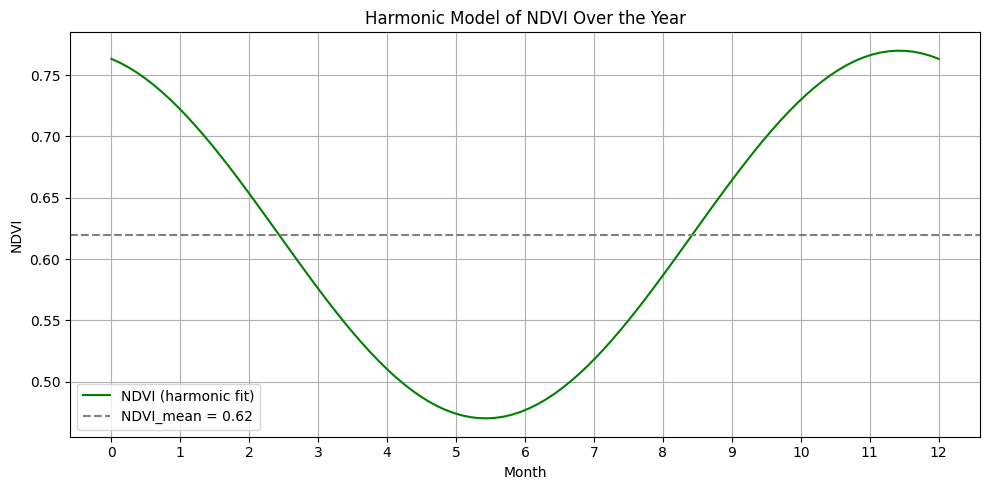

In [ ]:


import numpy as np
import matplotlib.pyplot as plt


NDVI_mean = 0.62
NDVI_amplitude = 0.15
NDVI_phase = 1.87


months = np.linspace(0, 12, 100)
T = 12


ndvi_curve = NDVI_mean + NDVI_amplitude * np.sin((2 * np.pi * months / T) + NDVI_phase)


plt.figure(figsize=(10, 5))
plt.plot(months, ndvi_curve, label="NDVI (harmonic fit)", color='green')
plt.axhline(y=NDVI_mean, color='gray', linestyle='--', label=f"NDVI_mean = {NDVI_mean}")
plt.title("Harmonic Model of NDVI Over the Year")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(ticks=np.arange(0, 13, 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


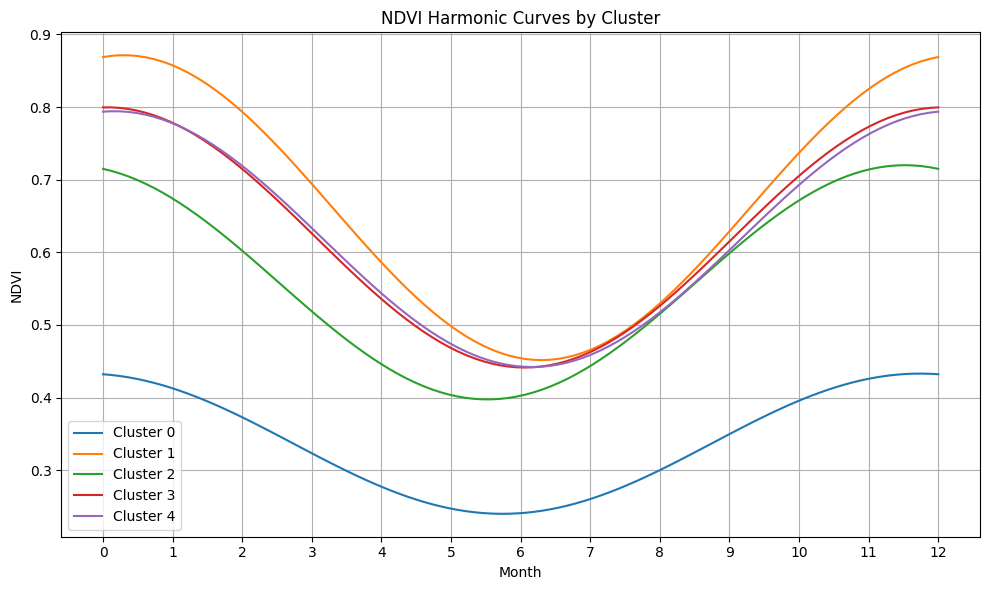

In [ ]:


import numpy as np
import matplotlib.pyplot as plt


harmonic_cols = ['NDVI_mean', 'NDVI_amplitude', 'NDVI_phase']


centroids = kmeans.cluster_centers_
means = scaler.mean_[:len(harmonic_cols)]
stds = scaler.scale_[:len(harmonic_cols)]


de_standardized = centroids[:, :len(harmonic_cols)] * stds + means


months = np.linspace(0, 12, 100)
T = 12


plt.figure(figsize=(10, 6))

for i, (mean, amp, phase) in enumerate(de_standardized):
    ndvi_curve = mean + amp * np.sin((2 * np.pi * months / T) + phase)
    plt.plot(months, ndvi_curve, label=f"Cluster {i}")

plt.title("NDVI Harmonic Curves by Cluster")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(ticks=np.arange(0, 13, 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


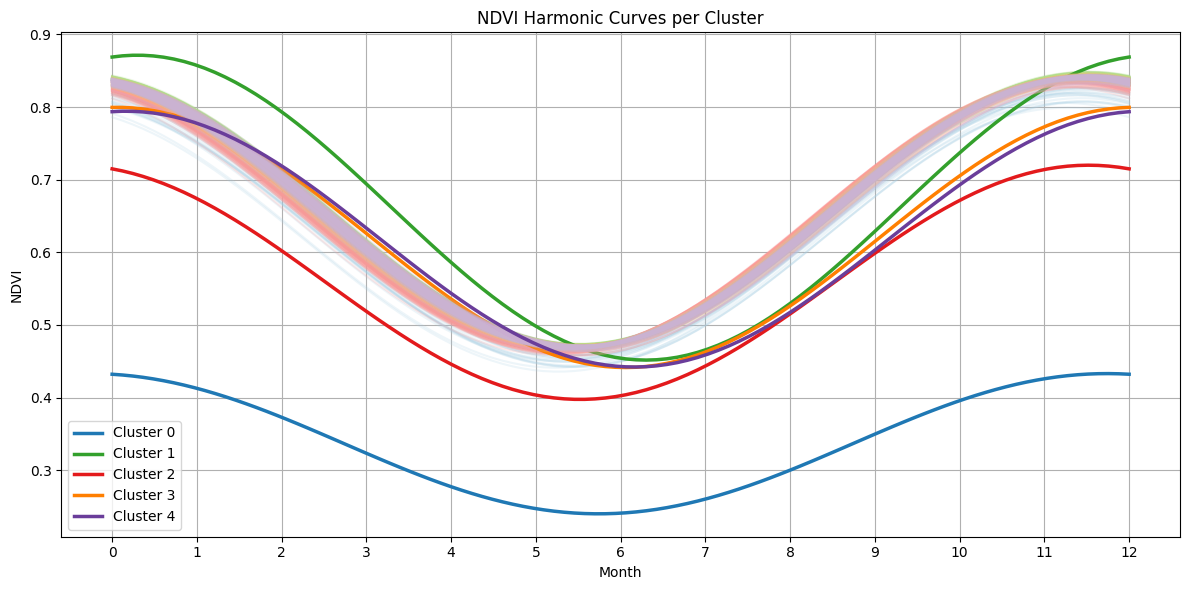

In [ ]:


import matplotlib.pyplot as plt
import numpy as np


months = np.linspace(0, 12, 100)
T = 12


plt.figure(figsize=(12, 6))


harmonic_cols = ['NDVI_mean', 'NDVI_amplitude', 'NDVI_phase']
harmonic_indices = [df.columns.get_loc(col) for col in harmonic_cols]


means = scaler.mean_[:len(harmonic_cols)]
stds = scaler.scale_[:len(harmonic_cols)]


cluster_centers = kmeans.cluster_centers_[:, :len(harmonic_cols)]
cluster_centers = cluster_centers * stds + means


colors = ['#a6cee3', '#b2df8a', '#fb9a99', '#fdbf6f', '#cab2d6']
dark_colors = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a']


for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id].copy()


    for i, col in enumerate(harmonic_cols):
        cluster_df[col + '_real'] = cluster_df[col] * stds[i] + means[i]


    for _, row in cluster_df.iterrows():
        mean = row['NDVI_mean_real']
        amp = row['NDVI_amplitude_real']
        phase = row['NDVI_phase_real']
        curve = mean + amp * np.sin((2 * np.pi * months / T) + phase)
        plt.plot(months, curve, color=colors[cluster_id], alpha=0.2)



    mean_c, amp_c, phase_c = cluster_centers[cluster_id]
    centroid_curve = mean_c + amp_c * np.sin((2 * np.pi * months / T) + phase_c)
    plt.plot(months, centroid_curve, color=dark_colors[cluster_id], label=f'Cluster {cluster_id}', linewidth=2.5)


plt.title("NDVI Harmonic Curves per Cluster")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(ticks=np.arange(0, 13, 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


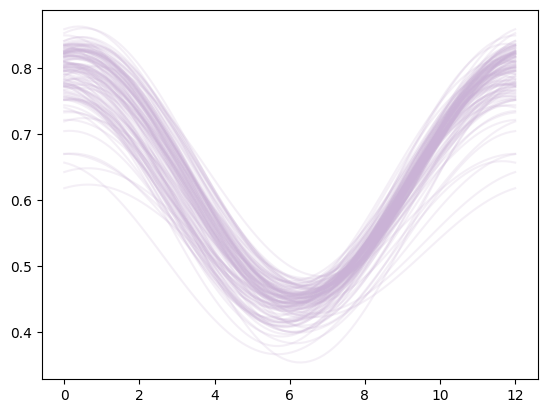

In [ ]:

for _, row in cluster_df.iterrows():
    mean = row['NDVI_mean']
    amp = row['NDVI_amplitude']
    phase = row['NDVI_phase']
    curve = mean + amp * np.sin((2 * np.pi * months / T) + phase)
    plt.plot(months, curve, color=colors[cluster_id], alpha=0.2)
